# HOG-based Person Re-ID Pipeline (Optimized)
## Dataset: Market-1501

# CELL 1 — IMPORT LIBRARIES

In [1]:
import os
import re
import cv2
import time
import warnings
import numpy as np

from tqdm import tqdm
from skimage.feature import hog
from scipy.spatial.distance import cdist

warnings.filterwarnings("ignore")

# CELL 2 — DATASET CONFIG

In [6]:
# =========================
# CHANGE THIS PATH
# =========================
DATASET_ROOT = "Market-1501-v15.09.15"

QUERY_DIR = os.path.join(DATASET_ROOT, "query")
GALLERY_DIR = os.path.join(DATASET_ROOT, "bounding_box_test")

CACHE_DIR = "hog_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

# CELL 3 — DATASET CLASS

In [7]:
class Market1501Dataset:
    
    _FNAME_PATTERN = re.compile(r"(-?\d+)_c(\d+)")

    def __init__(self, root):
        self.root = root

        self.query = self._load_split("query")
        self.gallery = self._load_split("bounding_box_test")

        print(f"Query images  : {len(self.query)}")
        print(f"Gallery images: {len(self.gallery)}")

    def _parse_filename(self, fname):
        match = self._FNAME_PATTERN.search(fname)

        if not match:
            return None, None

        pid = int(match.group(1))
        cid = int(match.group(2))

        return pid, cid

    def _load_split(self, split_name):
        split_dir = os.path.join(self.root, split_name)

        records = []

        for fname in sorted(os.listdir(split_dir)):

            if not fname.lower().endswith(".jpg"):
                continue

            pid, cid = self._parse_filename(fname)

            if pid is None:
                continue

            # remove junk images
            if pid <= 0:
                continue

            records.append({
                "path": os.path.join(split_dir, fname),
                "pid": pid,
                "cid": cid,
                "fname": fname,
            })

        return records

    def get_paths(self, split="query"):
        data = self.query if split == "query" else self.gallery
        return [x["path"] for x in data]

    def get_pids(self, split="query"):
        data = self.query if split == "query" else self.gallery
        return np.array([x["pid"] for x in data], dtype=np.int32)

    def get_cids(self, split="query"):
        data = self.query if split == "query" else self.gallery
        return np.array([x["cid"] for x in data], dtype=np.int32)

# CELL 4 — LOAD DATASET

In [8]:
dataset = Market1501Dataset(DATASET_ROOT)

query_paths = dataset.get_paths("query")
gallery_paths = dataset.get_paths("gallery")

q_pids = dataset.get_pids("query")
g_pids = dataset.get_pids("gallery")

q_cids = dataset.get_cids("query")
g_cids = dataset.get_cids("gallery")

Query images  : 3368
Gallery images: 13115


# CELL 5 — OPTIMIZED HOG FEATURE EXTRACTOR

In [9]:
class OptimizedHOGExtractor:

    def __init__(
        self,
        img_h=128,
        img_w=64,
        orientations=12,
        ppc=(8, 8),
        cpb=(2, 2),
    ):

        self.img_h = img_h
        self.img_w = img_w

        self.orientations = orientations
        self.ppc = ppc
        self.cpb = cpb

        dummy = np.zeros((img_h, img_w), dtype=np.float32)

        feat = hog(
            dummy,
            orientations=self.orientations,
            pixels_per_cell=self.ppc,
            cells_per_block=self.cpb,
            block_norm="L2-Hys",
            feature_vector=True,
        )

        self.single_channel_dim = len(feat)

        # RGB-HOG => x3
        self.feature_dim = self.single_channel_dim * 3

        print(f"Feature dimension: {self.feature_dim}")

    def preprocess(self, img_bgr):

        img = cv2.resize(
            img_bgr,
            (self.img_w, self.img_h),
            interpolation=cv2.INTER_LINEAR,
        )

        # convert to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = img.astype(np.float32) / 255.0

        return img

    def extract_single(self, img_path):

        img = cv2.imread(img_path)

        if img is None:
            return np.zeros(self.feature_dim, dtype=np.float32)

        img = self.preprocess(img)

        feats = []

        # HOG on each RGB channel
        for c in range(3):

            feat = hog(
                img[:, :, c],
                orientations=self.orientations,
                pixels_per_cell=self.ppc,
                cells_per_block=self.cpb,
                block_norm="L2-Hys",
                feature_vector=True,
            )

            feats.append(feat)

        feat = np.concatenate(feats).astype(np.float32)

        return feat

    def extract_batch(self, img_paths, cache_name=None):

        cache_path = None

        if cache_name is not None:
            cache_path = os.path.join(CACHE_DIR, cache_name)

            if os.path.exists(cache_path):
                print(f"Loading cached features: {cache_path}")
                return np.load(cache_path)

        features = []

        for path in tqdm(img_paths):
            feat = self.extract_single(path)
            features.append(feat)

        features = np.array(features, dtype=np.float32)

        # IMPORTANT: L2 normalization
        features /= (
            np.linalg.norm(features, axis=1, keepdims=True) + 1e-12
        )

        if cache_path is not None:
            np.save(cache_path, features)
            print(f"Saved cache: {cache_path}")

        return features

# CELL 6 — EXTRACT FEATURES

In [10]:
extractor = OptimizedHOGExtractor(
    img_h=128,
    img_w=64,
    orientations=12,
    ppc=(8, 8),
    cpb=(2, 2),
)

print("\nExtracting QUERY features...")
start = time.time()

query_feats = extractor.extract_batch(
    query_paths,
    cache_name="query_feats.npy",
)

print(query_feats.shape)
print(f"Time: {time.time() - start:.1f}s")

print("\nExtracting GALLERY features...")
start = time.time()

gallery_feats = extractor.extract_batch(
    gallery_paths,
    cache_name="gallery_feats.npy",
)

print(gallery_feats.shape)
print(f"Time: {time.time() - start:.1f}s")

Feature dimension: 15120

Extracting QUERY features...


100%|██████████| 3368/3368 [00:29<00:00, 114.62it/s]


Saved cache: hog_cache\query_feats.npy
(3368, 15120)
Time: 30.0s

Extracting GALLERY features...


100%|██████████| 13115/13115 [01:38<00:00, 132.99it/s]


Saved cache: hog_cache\gallery_feats.npy
(13115, 15120)
Time: 100.7s


# CELL 7 — FAST COSINE DISTANCE

In [11]:
# cosine distance = 1 - cosine similarity

start = time.time()

# MUCH faster than scipy cdist

dist_mat = 1.0 - np.matmul(
    query_feats,
    gallery_feats.T,
)

print(dist_mat.shape)
print(f"Distance computation time: {time.time() - start:.2f}s")

(3368, 13115)
Distance computation time: 3.56s


# CELL 8 — PRECOMPUTE SORTING

In [12]:
# avoid sorting multiple times

sorted_indices = np.argsort(dist_mat, axis=1)

print(sorted_indices.shape)

(3368, 13115)


# CELL 9 — EVALUATOR

In [13]:
class ReIDEvaluator:

    def __init__(self, top_k=10):
        self.top_k = top_k

    def get_matches(
        self,
        q_pid,
        q_cid,
        g_pids,
        g_cids,
        ranked_indices,
    ):

        is_junk = (g_pids == q_pid) & (g_cids == q_cid)
        is_match = (g_pids == q_pid) & (g_cids != q_cid)

        num_gt = is_match.sum()

        if num_gt == 0:
            return None, 0

        matches = []

        for idx in ranked_indices:

            if is_junk[idx]:
                continue

            matches.append(1 if is_match[idx] else 0)

        return np.array(matches), int(num_gt)

    def compute_rank1(
        self,
        sorted_indices,
        q_pids,
        g_pids,
        q_cids,
        g_cids,
    ):

        correct = 0
        valid_queries = 0

        for q_idx in range(len(q_pids)):

            matches, num_gt = self.get_matches(
                q_pids[q_idx],
                q_cids[q_idx],
                g_pids,
                g_cids,
                sorted_indices[q_idx],
            )

            if matches is None:
                continue

            valid_queries += 1

            if len(matches) > 0 and matches[0] == 1:
                correct += 1

        return correct / valid_queries

    def compute_map(
        self,
        sorted_indices,
        q_pids,
        g_pids,
        q_cids,
        g_cids,
    ):

        ap_list = []

        for q_idx in range(len(q_pids)):

            matches, num_gt = self.get_matches(
                q_pids[q_idx],
                q_cids[q_idx],
                g_pids,
                g_cids,
                sorted_indices[q_idx],
            )

            if matches is None:
                continue

            correct = 0
            ap = 0.0

            for k, rel in enumerate(matches, start=1):

                if rel == 1:
                    correct += 1
                    ap += correct / k

            ap /= num_gt

            ap_list.append(ap)

        return np.mean(ap_list)

    def compute_cmc(
        self,
        sorted_indices,
        q_pids,
        g_pids,
        q_cids,
        g_cids,
        ranks=[1, 5, 10, 20],
    ):

        results = {}

        for rank in ranks:

            correct = 0
            valid = 0

            for q_idx in range(len(q_pids)):

                matches, num_gt = self.get_matches(
                    q_pids[q_idx],
                    q_cids[q_idx],
                    g_pids,
                    g_cids,
                    sorted_indices[q_idx],
                )

                if matches is None:
                    continue

                valid += 1

                topk = matches[:rank]

                if topk.sum() > 0:
                    correct += 1

            results[f"Rank-{rank}"] = correct / valid

        return results

    def compute_f1_at_k(
        self,
        sorted_indices,
        q_pids,
        g_pids,
        q_cids,
        g_cids,
    ):

        f1_scores = []
        precisions = []
        recalls = []

        k = self.top_k

        for q_idx in range(len(q_pids)):

            matches, num_gt = self.get_matches(
                q_pids[q_idx],
                q_cids[q_idx],
                g_pids,
                g_cids,
                sorted_indices[q_idx],
            )

            if matches is None:
                continue

            topk = matches[:k]

            tp = topk.sum()

            precision = tp / len(topk)
            recall = tp / num_gt

            if precision + recall > 0:
                f1 = 2 * precision * recall / (precision + recall)
            else:
                f1 = 0

            f1_scores.append(f1)
            precisions.append(precision)
            recalls.append(recall)

        return {
            "f1": np.mean(f1_scores),
            "precision": np.mean(precisions),
            "recall": np.mean(recalls),
        }

# CELL 10 — RUN EVALUATION

In [14]:
evaluator = ReIDEvaluator(top_k=10)

start = time.time()

rank1 = evaluator.compute_rank1(
    sorted_indices,
    q_pids,
    g_pids,
    q_cids,
    g_cids,
)

map_score = evaluator.compute_map(
    sorted_indices,
    q_pids,
    g_pids,
    q_cids,
    g_cids,
)

cmc_scores = evaluator.compute_cmc(
    sorted_indices,
    q_pids,
    g_pids,
    q_cids,
    g_cids,
)

f1_results = evaluator.compute_f1_at_k(
    sorted_indices,
    q_pids,
    g_pids,
    q_cids,
    g_cids,
)

print(f"Evaluation time: {time.time() - start:.2f}s")

Evaluation time: 198.44s


# CELL 11 — FINAL RESULTS

In [15]:
print("=" * 60)
print("OPTIMIZED HOG PERSON Re-ID RESULTS")
print("=" * 60)

print(f"Rank-1 Accuracy : {rank1 * 100:.2f}%")
print(f"mAP             : {map_score * 100:.2f}%")

print("\nCMC Results")
print("-" * 60)

for k, v in cmc_scores.items():
    print(f"{k:<10}: {v * 100:.2f}%")

print("\nF1 Results")
print("-" * 60)

print(f"F1@10       : {f1_results['f1'] * 100:.2f}%")
print(f"Precision@10: {f1_results['precision'] * 100:.2f}%")
print(f"Recall@10   : {f1_results['recall'] * 100:.2f}%")

print("=" * 60)

OPTIMIZED HOG PERSON Re-ID RESULTS
Rank-1 Accuracy : 4.33%
mAP             : 1.20%

CMC Results
------------------------------------------------------------
Rank-1    : 4.33%
Rank-5    : 9.26%
Rank-10   : 12.86%
Rank-20   : 18.05%

F1 Results
------------------------------------------------------------
F1@10       : 1.48%
Precision@10: 1.82%
Recall@10   : 1.44%


# CELL 12 — OPTIONAL: SAVE RESULTS

In [16]:
results = {
    "rank1": rank1,
    "map": map_score,
    "cmc": cmc_scores,
    "f1": f1_results,
}

np.save("hog_reid_results.npy", results)

print("Results saved.")

Results saved.


# Retrieval Demo

In [18]:
import matplotlib.pyplot as plt

def show_topk_results(
    query_idx,
    top_k=5,
):

    q_path = query_paths[query_idx]

    ranked = sorted_indices[query_idx]

    plt.figure(figsize=(15, 4))

    # QUERY
    q_img = cv2.cvtColor(cv2.imread(q_path), cv2.COLOR_BGR2RGB)

    plt.subplot(1, top_k + 1, 1)
    plt.imshow(q_img)
    plt.title("QUERY")
    plt.axis("off")

    count = 0

    for idx in ranked:

        g_pid = g_pids[idx]
        q_pid = q_pids[query_idx]

        g_cid = g_cids[idx]
        q_cid = q_cids[query_idx]

        # remove junk
        if g_pid == q_pid and g_cid == q_cid:
            continue

        g_path = gallery_paths[idx]

        similarity = 1.0 - dist_mat[query_idx, idx]

        img = cv2.cvtColor(cv2.imread(g_path), cv2.COLOR_BGR2RGB)

        plt.subplot(1, top_k + 1, count + 2)
        plt.imshow(img)

        title = (
            f"Rank-{count+1}\n"
            f"Sim={similarity:.3f}\n"
            f"Cam={g_cid}"
        )

        plt.title(title)
        plt.axis("off")

        count += 1

        if count >= top_k:
            break

    plt.tight_layout()
    plt.show()

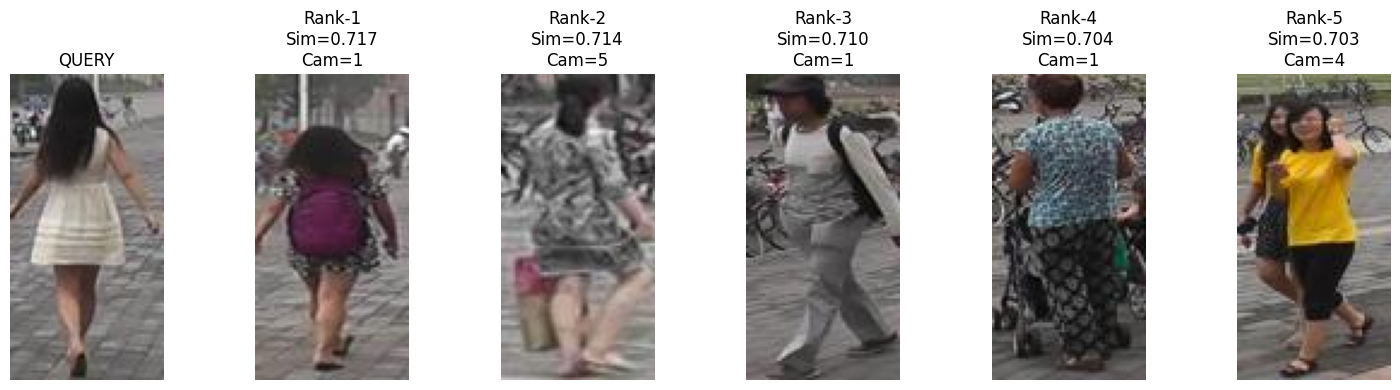

In [19]:
show_topk_results(
    query_idx=0,
    top_k=5,
)